# Simulación de Glioblastoma en 2D (Medio Heterogéneo)


En la siguiente celda, se importan las herramientas matemáticas básicas y la librería `nibabel` para la lectura del espacio anatómico.

In [21]:

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib

# estilo de los gráficos para que se vean bien en el notebook
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['image.cmap'] = 'inferno' # Un mapa de colores excelente para ver el tumor brillar

# Parámetros Físicos y Computacionales
## Resolución Espacial: 
La resonancia magnética MINC tiene una resolución isométrica de 1x1x1 mm, por lo tanto el paso espacial será de 1 mm.
## Condición de Estabilidad (CFL): 
Para el paso temporal ($\Delta t$), el método explícito nos obliga a cumplir el criterio de Courant-Friedrichs-Lewy. El tiempo máximo permitido depende de la difusión más rápida (la sustancia blanca, D = 0.05). 
Matemáticamente:  $$\Delta t \leq \frac{\Delta x^2}{4 \cdot D_{max}} = \frac{1}{4 \cdot 0.05} = 5$$
Usaremos un paso temporal seguro de 0.5 días.

In [22]:


# parámetros del modelo de difusión
D_blanca = 0.05  # Tasa de difusión celular en sustancia blanca (mm^2 / día)
D_gris = 0.01    # Tasa de difusión celular en sustancia gris (mm^2 / día)
D_cero = 0.0     # Frontera impenetrable (cráneo/fluido)
rho = 0.025      # Tasa de proliferación (multiplicación) logística (1 / día)

# Parámetros Espaciales de la Malla
dx = 1.0         # Tamaño del píxel en X (mm)
dy = 1.0         # Tamaño del píxel en Y (mm)

# Parámetros Temporales (Criterio de Estabilidad CFL)
dt = 0.5         # Paso temporal (días)
dias_simulacion = 400 # Tiempo clínico total a simular

# Cálculos automáticos para el ciclo 'for'
pasos_tiempo = int(dias_simulacion / dt)

print(f"Simulación de {dias_simulacion} días configurada.")
print(f"Iteraciones totales (ciclos): {pasos_tiempo}")
print(f"Criterio CFL máximo permitido: { (dx**2) / (4*D_blanca) } días.")
print(f"Paso dt seleccionado: {dt} días (Estable).")

Simulación de 400 días configurada.
Iteraciones totales (ciclos): 800
Criterio CFL máximo permitido: 5.0 días.
Paso dt seleccionado: 0.5 días (Estable).


## Construcción del Dominio Espacial $D(x,y)$

En lugar de construir la matriz localmente, llamaremos a nuestro script de preprocesamiento. Este script lee el archivo MINC, segmenta los tejidos según las intensidades T1 y genera la matriz de difusión `matriz_D`.

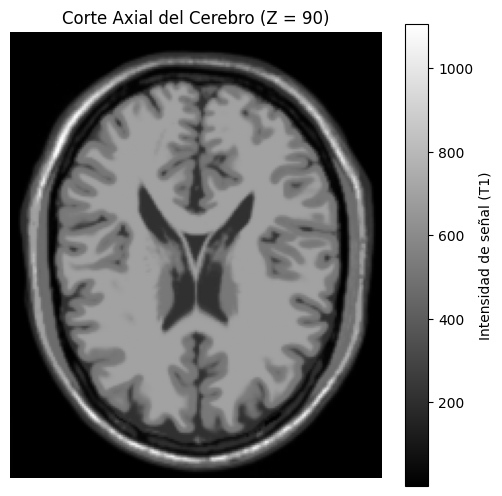

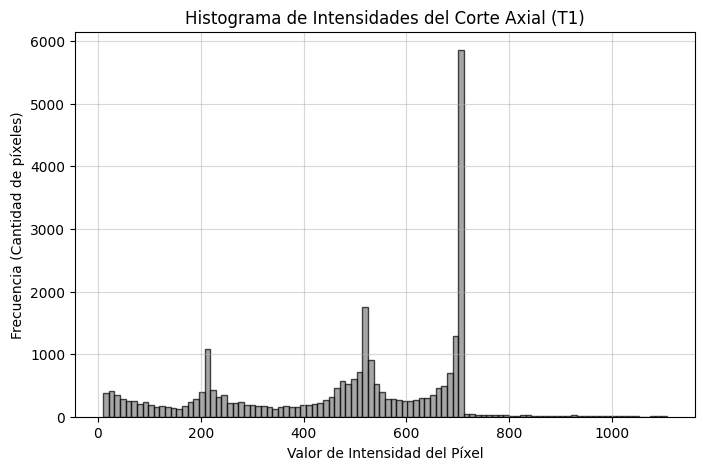

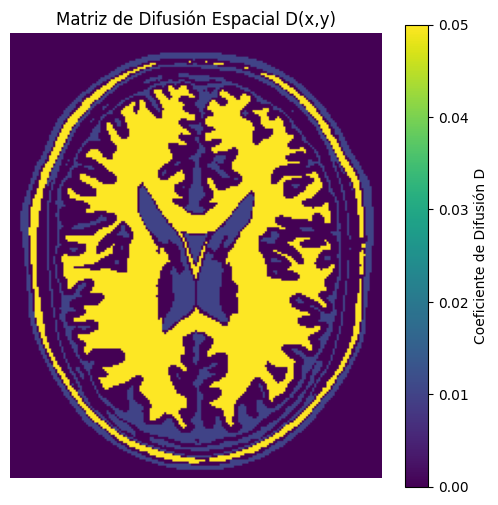

¡Matriz de difusión cargada con éxito!
Dimensiones del dominio: (217, 181)


In [23]:
#cargar la matriz de difusión D desde el archivo MINC

# Usamos '../' para salir de 'notebooks' y entrar a 'codigos'
# (Nota: Verifica si tu carpeta se llama 'codigos' o 'Codigos' con mayúscula, Windows es sensible a esto)
%run ../Codigos/cerebro_2D.py

# Verificamos que la variable se haya cargado correctamente en la memoria
print(f"¡Matriz de difusión cargada con éxito!")
print(f"Dimensiones del dominio: {matriz_D.shape}")

## Condiciones Iniciales: Semilla del Tumor

Para resolver la ecuación diferencial en el tiempo, necesitamos definir el estado $u(x,y,t=0)$. Crearemos una matriz $u$ inicialmente vacía e inyectaremos un núcleo tumoral esférico (circular en 2D) en una región válida del cerebro (donde $D \neq 0$).

Semilla tumoral plantada con éxito en (118, 70)


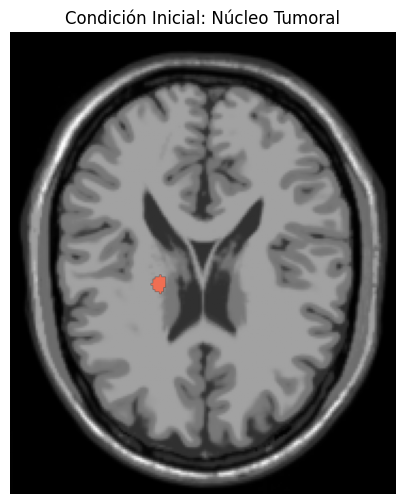

In [24]:

# 1. Matriz de concentración celular vacía
u = np.zeros_like(matriz_D)

# 2. Elegimos las coordenadas del centro del tumor original
# Buscamos un punto cercano al centro del cerebro (ajustable según la anatomía)
centro_x = matriz_D.shape[0] // 2 + 10
centro_y = matriz_D.shape[1] // 2 - 20

# Verificamos la física matemática: ¡El tumor no puede nacer en el cráneo!
if matriz_D[centro_x, centro_y] == D_cero:
    print("⚠️ ADVERTENCIA: La coordenada central cae en una zona muerta (D=0).")
    print("El tumor no crecerá. Ajusta centro_x y centro_y.")

# 3. Tamaño inicial del tumor (radio en mm) y concentración
radio_inicial = 4.0
concentracion_inicial = 0.5 # Normalizada (1.0 sería la capacidad máxima de carga del tejido)

# 4. Inyectamos la semilla usando la ecuación de un círculo
for i in range(u.shape[0]):
    for j in range(u.shape[1]):
        # Distancia euclidiana al cuadrado desde el centro
        distancia_cuadrada = (i - centro_x)**2 + (j - centro_y)**2
        
        # Si estamos dentro del radio Y el tejido no es cráneo/vacío
        if distancia_cuadrada <= radio_inicial**2 and matriz_D[i, j] != D_cero:
            u[i, j] = concentracion_inicial

print(f"Semilla tumoral plantada con éxito en ({centro_x}, {centro_y})")

# 5. Visualización para comprobar que plantamos bien la semilla
plt.figure(figsize=(6, 6))
# Dibujamos la anatomía de fondo en escala de grises
plt.imshow(corte_axial, cmap='gray')
# Superponemos el tumor usando un mapa de colores 'Reds' y algo de transparencia
u_masked = np.ma.masked_where(u == 0, u) # Ocultamos los ceros para ver el fondo
plt.imshow(u_masked, cmap='Reds', alpha=0.9, vmin=0, vmax=1)
plt.title('Condición Inicial: Núcleo Tumoral')
plt.axis('off')
plt.show()

## El Motor Numérico: Integración Temporal (Método FTCS)

Aquí resolvemos la ecuación diferencial parcial mediante el método de diferencias finitas (esquema explícito de Euler). Iteramos sobre cada paso de tiempo y actualizamos la concentración celular en cada punto del espacio.

Para tratar la heterogeneidad espacial, la divergencia del flujo $\nabla \cdot (D \nabla u)$ se discretiza calculando promedios aritméticos del coeficiente de difusión en las interfaces de la malla (los "puentes").

In [25]:


import time

# Preparamos las matrices para guardar el estado actual y el futuro
u_actual = np.copy(u)
u_siguiente = np.zeros_like(u)

print("Iniciando simulación del crecimiento tumoral...")
tiempo_inicio = time.time()

# Ciclo principal en el tiempo
for t in range(pasos_tiempo):
    
    # Recorremos la grilla espacial (evitamos los bordes extremos para no salir de la matriz)
    for i in range(1, u_actual.shape[0] - 1):
        for j in range(1, u_actual.shape[1] - 1):
            
            # OPTIMIZACIÓN FÍSICA: Solo calculamos si estamos dentro del cerebro y si hay células cerca
            if matriz_D[i, j] > 0.0:
                
                # 1. Calculamos los "puentes" de difusión (promedios espaciales en las interfaces)
                D_der = (matriz_D[i+1, j] + matriz_D[i, j]) / 2.0
                D_izq = (matriz_D[i-1, j] + matriz_D[i, j]) / 2.0
                D_arr = (matriz_D[i, j+1] + matriz_D[i, j]) / 2.0
                D_aba = (matriz_D[i, j-1] + matriz_D[i, j]) / 2.0
                
                # 2. Operador Laplaciano Heterogéneo (Flujo neto de células hacia el píxel i,j)
                flujo_x = D_der * (u_actual[i+1, j] - u_actual[i, j]) - D_izq * (u_actual[i, j] - u_actual[i-1, j])
                flujo_y = D_arr * (u_actual[i, j+1] - u_actual[i, j]) - D_aba * (u_actual[i, j] - u_actual[i, j-1])
                
                difusion = (flujo_x / (dx**2)) + (flujo_y / (dy**2))
                
                # 3. Término de Reacción Logística (Proliferación local)
                reaccion = rho * u_actual[i, j] * (1.0 - u_actual[i, j])
                
                # 4. Actualización temporal (Método de Euler Explícito)
                u_siguiente[i, j] = u_actual[i, j] + dt * (difusion + reaccion)
                
    # Sobreescribimos la matriz actual con los nuevos valores calculados
    u_actual = np.copy(u_siguiente)
    
    # Imprimimos progreso para no pensar que el programa se quedó pegado
    if (t + 1) % 50 == 0:
        print(f"Progreso: Paso {t + 1}/{pasos_tiempo} (Día clínico {(t+1)*dt}) completado.")

tiempo_fin = time.time()
print(f"¡Simulación terminada con éxito en {round(tiempo_fin - tiempo_inicio, 2)} segundos!")

Iniciando simulación del crecimiento tumoral...
Progreso: Paso 50/800 (Día clínico 25.0) completado.
Progreso: Paso 100/800 (Día clínico 50.0) completado.
Progreso: Paso 150/800 (Día clínico 75.0) completado.
Progreso: Paso 200/800 (Día clínico 100.0) completado.
Progreso: Paso 250/800 (Día clínico 125.0) completado.
Progreso: Paso 300/800 (Día clínico 150.0) completado.
Progreso: Paso 350/800 (Día clínico 175.0) completado.
Progreso: Paso 400/800 (Día clínico 200.0) completado.
Progreso: Paso 450/800 (Día clínico 225.0) completado.
Progreso: Paso 500/800 (Día clínico 250.0) completado.
Progreso: Paso 550/800 (Día clínico 275.0) completado.
Progreso: Paso 600/800 (Día clínico 300.0) completado.
Progreso: Paso 650/800 (Día clínico 325.0) completado.
Progreso: Paso 700/800 (Día clínico 350.0) completado.
Progreso: Paso 750/800 (Día clínico 375.0) completado.
Progreso: Paso 800/800 (Día clínico 400.0) completado.
¡Simulación terminada con éxito en 118.05 segundos!


## Resultados: Expansión del Tumor a los 150 Días

Visualizamos el estado final de la densidad celular $u(x,y, t_{final})$ superpuesta sobre la resonancia magnética anatómica del paciente. Observaremos cómo el crecimiento ha dejado de ser radial e isotrópico, deformándose para seguir las "autopistas" de la sustancia blanca.

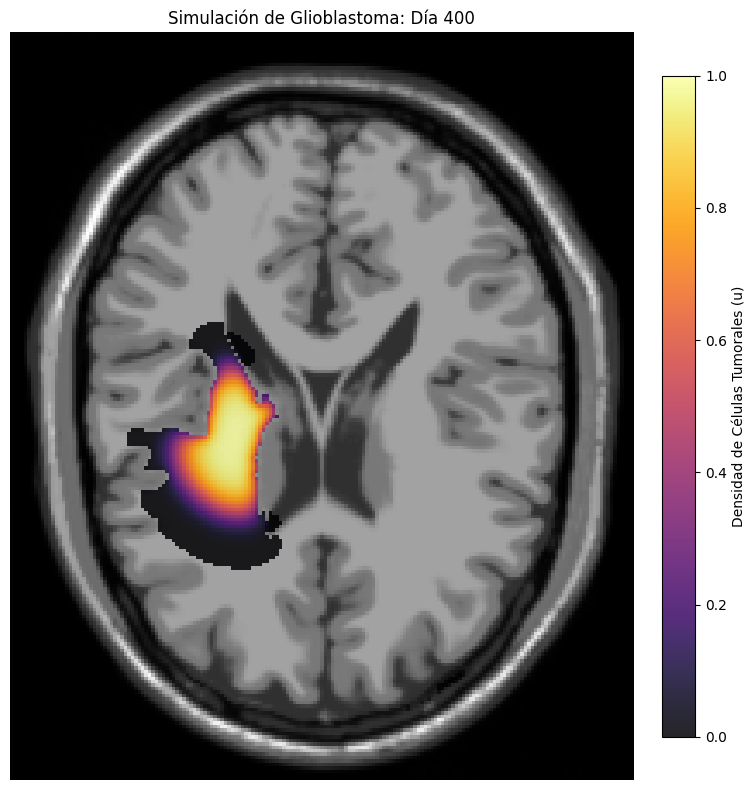

In [26]:
# ==========================================
# CELDA 6: VISUALIZACIÓN DEL TUMOR INVASIVO
# ==========================================

# Ocultamos los píxeles donde la concentración de células es casi nula
# para poder ver la anatomía del cerebro de fondo.
u_final_masked = np.ma.masked_where(u_actual < 0.0001, u_actual)

plt.figure(figsize=(8, 8))

# 1. Dibujamos el mapa anatómico (Resonancia T1) de fondo
plt.imshow(corte_axial, cmap='gray')

# 2. Superponemos la matriz del tumor. 
# El mapa 'inferno' es excelente porque va de negro/morado (baja densidad) a amarillo/blanco (alta densidad)
tumor_plot = plt.imshow(u_final_masked, cmap='inferno', alpha=0.85, vmin=0, vmax=1)

# 3. Detalles estéticos y barra de color
plt.title(f'Simulación de Glioblastoma: Día {dias_simulacion}')
plt.colorbar(tumor_plot, label='Densidad de Células Tumorales (u)', fraction=0.046, pad=0.04)
plt.axis('off')

plt.tight_layout()
plt.show()

Velocidad del Frente de Invasión

En esta sección extraemos un perfil unidimensional de la densidad celular $u$ pasando por el centro del tumor. Calcularemos la distancia que ha viajado el frente de onda (definido donde $u \approx 0.5$) y obtendremos la velocidad computacional ($v_{comp} = \frac{\Delta \text{Distancia}}{\Delta \text{Tiempo}}$). Finalmente, contrastaremos este resultado con las velocidades asintóticas teóricas de Fisher-KPP para la sustancia blanca ($v_w = 2\sqrt{D_w\rho}$) y la sustancia gris ($v_g = 2\sqrt{D_g\rho}$).

In [27]:
# ==========================================
# CELDA 7: EXTRACCIÓN DE VELOCIDADES POR TEJIDO (VERSIÓN ROBUSTA)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt

# 1. Definimos un umbral MÍNIMO de invasión (en lugar de una franja exacta)
# Buscaremos cualquier píxel que tenga AL MENOS un 1% de células
u_umbral = 0.01 

distancias_blanca = []
distancias_gris = []

# 2. Escaneamos TODA la matriz buscando la masa tumoral
for i in range(u_actual.shape[0]):
    for j in range(u_actual.shape[1]):
        
        # En lugar de buscar un valor exacto, tomamos TODA la zona invadida
        if u_actual[i, j] >= u_umbral:
            
            # Calculamos su distancia física al centro original
            distancia_mm = np.sqrt((i - centro_x)**2 + (j - centro_y)**2) * dx
            
            # 3. CRUCE DE DATOS: Revisamos en qué tejido está parado este píxel
            if matriz_D[i, j] == D_blanca:
                distancias_blanca.append(distancia_mm)
            elif matriz_D[i, j] == D_gris:
                distancias_gris.append(distancia_mm)

# 4. Obtenemos el avance máximo (el píxel invadido más alejado) en cada tejido
# Si la lista está vacía, devuelve 0 (aunque con >= 0.01 ya no debería estar vacía)
avance_blanca = max(distancias_blanca) if distancias_blanca else 0
avance_gris = max(distancias_gris) if distancias_gris else 0

# 5. Calculamos las velocidades computacionales
v_comp_blanca = (avance_blanca - radio_inicial) / dias_simulacion
v_comp_gris = (avance_gris - radio_inicial) / dias_simulacion

# Predicciones teóricas (Fisher local)
v_teorica_blanca = 2 * np.sqrt(D_blanca * rho)
v_teorica_gris = 2 * np.sqrt(D_gris * rho)

# 6. Imprimir resultados con seguro contra etapas tempranas
print("-" * 60)
print(f" RESULTADOS: VELOCIDAD DEL FRENTE DE ONDA (Día {dias_simulacion})")
print("-" * 60)
print(f"Velocidad Teórica Blanca (v_w): {v_teorica_blanca:.4f} mm/día")
print(f"Velocidad Medida Blanca:        {v_comp_blanca:.4f} mm/día")
print("\n")
print(f"Velocidad Teórica Gris (v_g):   {v_teorica_gris:.4f} mm/día")

if avance_gris == 0:
    print("Velocidad Medida Gris:          [El tumor aún no invade la sustancia gris]")
else:
    print(f"Velocidad Medida Gris:          {v_comp_gris:.4f} mm/día")
print("-" * 60)

------------------------------------------------------------
 RESULTADOS: VELOCIDAD DEL FRENTE DE ONDA (Día 400)
------------------------------------------------------------
Velocidad Teórica Blanca (v_w): 0.0707 mm/día
Velocidad Medida Blanca:        0.0683 mm/día


Velocidad Teórica Gris (v_g):   0.0316 mm/día
Velocidad Medida Gris:          0.0562 mm/día
------------------------------------------------------------
